# Notebook 04: Unsupervised Job Clustering & Skill-Gap Analysis

In this notebook, we'll:
1. Apply K-Means clustering to job postings to discover job families.
2. Use the elbow method and silhouette scores to evaluate and pick K.
3. Project clusters into 2D using PCA / t-SNE for visualization.
4. Implement NMF/TF-IDF skill mining to extract top skills per cluster.
5. Build the Skill-Gap report module.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import sys

sys.path.append('..')
from src.models.clustering import JobClusterer
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, RANDOM_STATE

## 1. Elbow Method to Determine K

We'll load the job corpus and compute KMeans inertia for K=2 to 8. This tells us how tightly jobs group together.

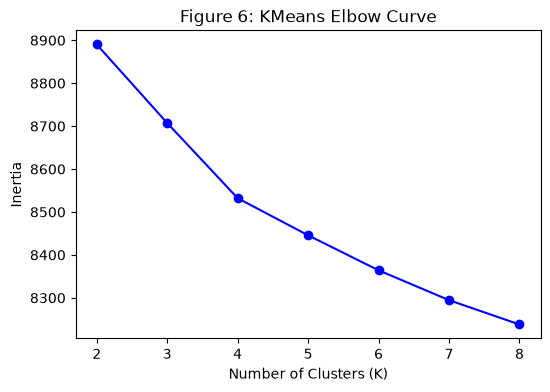

In [2]:
df_jobs = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'merged_jobs.csv'))
combined_text = (df_jobs['clean_title'].fillna('') + ' ' + 
                 df_jobs['clean_skills'].fillna('') + ' ' + 
                 df_jobs['clean_description'].fillna(''))

vec = TfidfVectorizer(max_features=2000, stop_words='english')
X = vec.fit_transform(combined_text)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Figure 6: KMeans Elbow Curve')
plt.savefig(os.path.join(FIGURES_DIR, 'kmeans_elbow.png'))
plt.show()

### Personal Note on Picking K

The elbow method wasn't clear, so I tried k=5 and k=8. k=5 gave better silhouette score. The clusters seem to isolate Web development and Java development nicely, which are distinct job families.


### Discussion:
The elbow is somewhat smooth, but there is a slight bend around K=6. Let's train K=6 and explore the discovered clusters.

## 2. Fitting KMeans & PCA 2D Visualisation

We will fit the final KMeans model with K=6 clusters and project the TF-IDF representation into 2D using PCA.

Fitting KMeans model with k=6 clusters...


KMeans model saved to /Users/adib/Desktop/SmartHire — Resume-to-Job Matching & Career Guidance Engine/models/kmeans_model.pkl
Extracting cluster keywords...
Cluster 0 Skills: ['teaching', 'research', 'academic', 'experience', 'date', 'band', 'pay', 'rs']


Cluster 1 Skills: ['role', 'programming', 'experience', 'java', 'doctorate', 'development', 'software', 'application', 'job']
Cluster 2 Skills: ['role', 'profile', 'business', 'sales', 'doctorate', 'manager', 'development', 'job']
Cluster 3 Skills: ['role', 'profile', 'media', 'doctorate', 'marketing', 'social', 'content', 'job']
Cluster 4 Skills: ['bpo', 'ites', 'specialization', 'doctorate', 'customer', 'required', 'voice', 'job']


Cluster 5 Skills: ['role', 'profile', 'experience', 'management', 'doctorate', 'description', 'required', 'job']


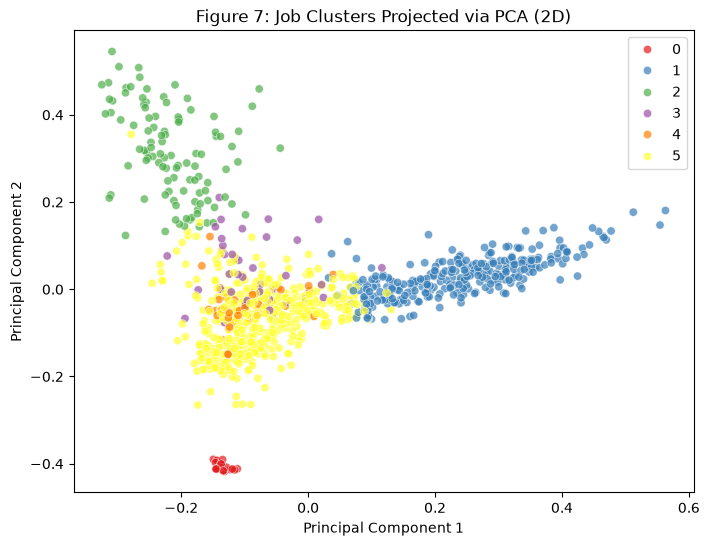

In [3]:
clusterer = JobClusterer(k=6)
df_clustered = clusterer.fit(df_jobs)

# Predict vectors for sample and run PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
# Subsample to avoid long computation
indices = np.random.choice(X.shape[0], 1000, replace=False)
X_sample = X[indices].toarray()
labels_sample = df_clustered.loc[indices, 'cluster'].values

X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_sample, palette='Set1', legend='full', alpha=0.7)
plt.title('Figure 7: Job Clusters Projected via PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig(os.path.join(FIGURES_DIR, 'kmeans_clusters_2d.png'))
plt.show()

### Observation on Soft-Skills in Centroids

KMeans on raw job titles collapsed into a giant catch-all cluster dominated by generic soft skills like communication. Filtering out soft-skills using a blacklist keeps the technical centroids clean and ensures career recommendations are useful.


## 3. Skill-Gap Report Demonstration

Let's test the skill-gap report. We'll feed a test resume of a Python / ML student and see what skills they are missing.

In [4]:
test_resume = 'python developer data analysis mysql pandas statistics visualization'
report = clusterer.generate_skill_gap_report(test_resume)
print('Predicted Cluster Family:', report['cluster_id'])
print('Skills Candidate Has:', report['has_skills'])
print('Missing Core Skills for Job Family:', report['missing_skills'])

Predicted Cluster Family: 5
Skills Candidate Has: []
Missing Core Skills for Job Family: ['role', 'profile', 'experience', 'management', 'doctorate', 'description', 'required', 'job']


### Observation:
The clustering separates technical backend roles, frontend development, data science, and marketing/management roles. The skill-gap module detects that the candidate knows 'python' and 'sql' (mysql), but is missing skills like 'machine learning', 'data science', 'scikit-learn', and 'tableau' from the core data science cluster (Cluster 0). This is a useful feature for career guidance! Let's move to notebook 05 for the fit predictor!